## primeira sessão de estudos para data science: **regressão linear**

a regressão linear é um método que encontra a melhor reta para explicar a relação entre uma variável x e uma variável y, mostrando como y muda quando x muda
é basicamente traçar a linha que melhor representa os dados.

para isso, começamos entendo o erro quadrático que é o quanto a reta erra ao tentar adivinhar o valor de y.

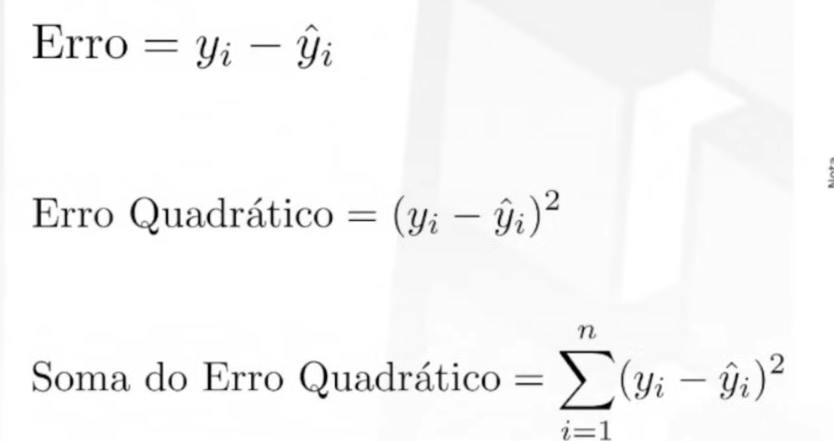

fonte: theo me why


isso gera diversas medidas, que, quendo somadas, me entregam a medida para me dizer o quanto estamos errando ao aproximar os valores da reta.

porém, eu preciso buscar a melhor reta para buscar o menor erro possível, assim **minizamos os erros quadráticos**

para isso, vamos buscar quais os coeficiente minimos, derivando e igualando a 0, dessa maneira encontramos os pontos minimos:

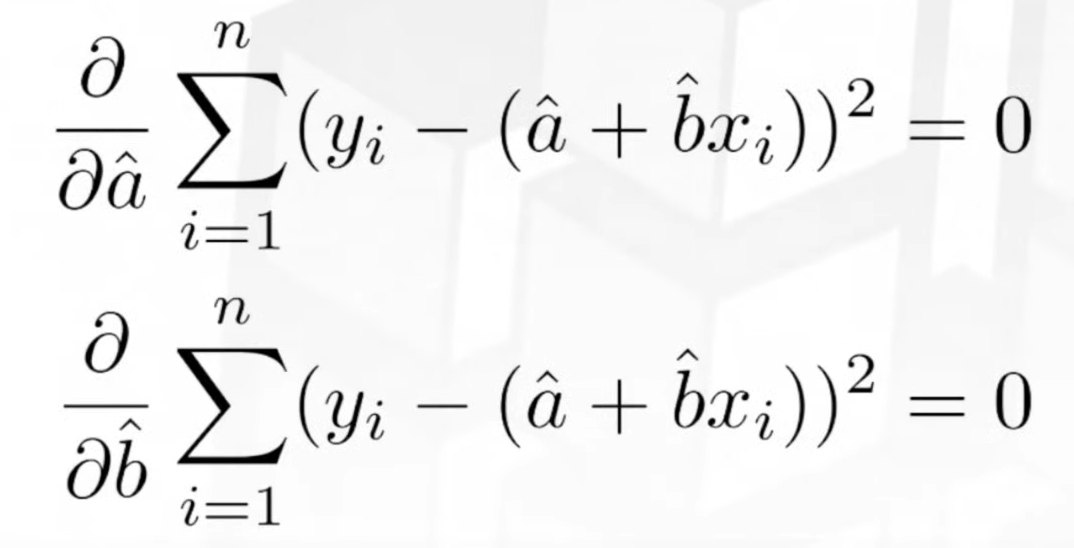

existem outros metodos para ajustar a reta, o utilizado no caso foi o **Método dos Mínimos Quadrados**

Modelo final de regressão linear:

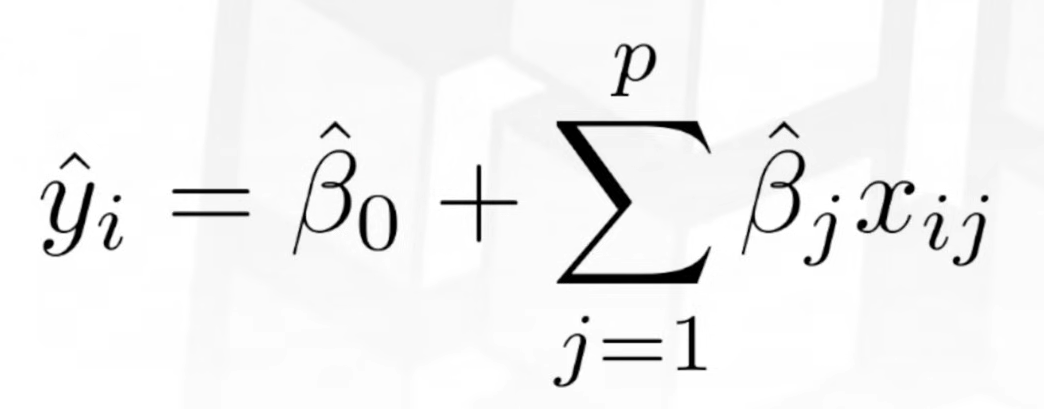

In [11]:
import pandas as pd

df = pd.read_csv('data\Salary_dataset.csv')

In [12]:
df.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [13]:
df.isnull().sum()

Unnamed: 0         0
YearsExperience    0
Salary             0
dtype: int64

In [15]:
df.describe()

,Unnamed: 0,YearsExperience,Salary
count,30.000000,30.000000,30.000000
mean,14.500000,5.413333,76004.000000
std,8.803408,2.837888,27414.429785
min,0.000000,1.200000,37732.000000
25%,7.250000,3.300000,56721.750000
50%,14.500000,4.800000,65238.000000
75%,21.750000,7.800000,100545.750000
max,29.000000,10.600000,122392.000000


In [21]:
df.columns

Index(['Unnamed: 0', 'YearsExperience', 'Salary'], dtype='object')

In [ ]:
from sklearn import linear_model

X = df[['YearsExperience']]     ## matriz, deve ser bidimensional pois os modelos esperam assim
y = df['Salary']                ## vetor, é o target

reg = linear_model.LinearRegression() ## that is ML !
reg.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [49]:
a,b = reg.coef_[0], reg.intercept_ ## visualizando os coeficientes
print(a,b)

9449.962321455074 24848.203966523208


In [ ]:
## fazendo a predição de salário para as idades
predict = reg.predict(X.drop_duplicates())

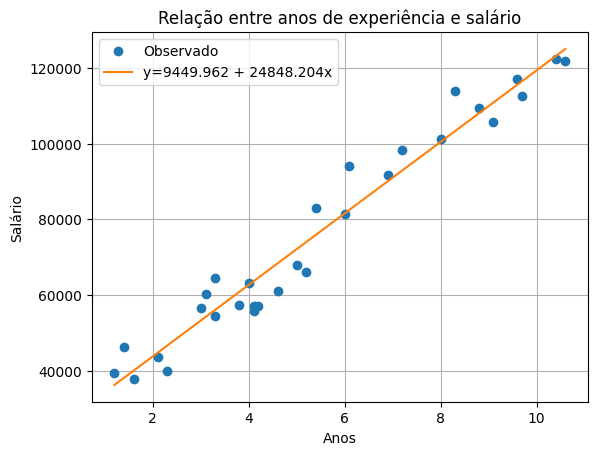

In [52]:
import matplotlib.pyplot as plt

plt.plot(X['YearsExperience'], y, 'o')
plt.grid(True)
plt.title("Relação entre anos de experiência e salário")
plt.xlabel("Anos")
plt.ylabel("Salário")

plt.plot(X.drop_duplicates()['YearsExperience'], predict)
plt.legend([f'Observado', f'y={a:.3f} + {b:.3f}x'])

o que isso significa?

essa linha representa a foi calculada atraves de um modelo de regressão linear, que a partir dos dados de salário e anos de experiencia, consegue prever com base nos anos de experiencia qual sera o seu salario aproximado. 

## segunda sessão de estudos para data science: **árvore de decisão**

já a arvore de decisão, divide a distribuição em 2 grupos, percorrendo todas as amostras possíveis e calculando a média dessas divisões.

o ponto aqui é entender: qual o melhor ponto de corte?

para isso, devemos encontrar a divisão onde a média tem o menor erro dentre os demais pontos.

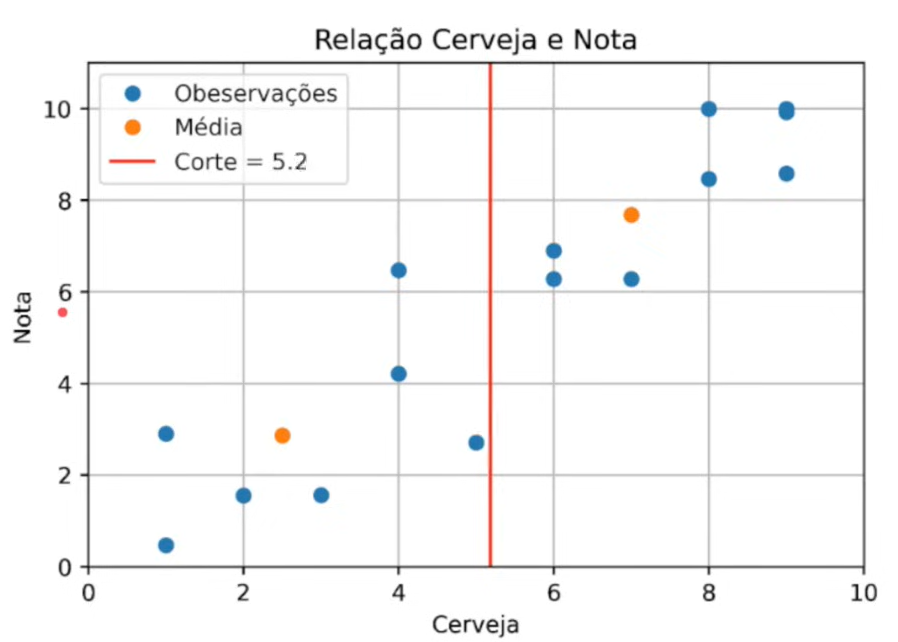

a arvore de decisão é exaustiva, o que significa que ela vai passar por todos os pontos até encontrar o melhor cenário.